# Эксперимент CatBoost на специальных признаках

Ноутбук обучает `CatBoostClassifier` на специальных данных из `data/X_train_catboost.csv` и `data/y_train_catboost.csv`.

Категориальные признаки берутся из `data/catboost_feature_metadata.json`. Это важно: CatBoost получает исходные категориальные колонки без one-hot encoding.

Числовые `NaN` не запрещаются: CatBoost умеет работать с пропусками в числовых признаках. Бесконечные значения `inf/-inf` заменяются на `NaN`.

Для балансировки классов используется CatBoost-аналог `class_weight="balanced"`: параметр `auto_class_weights="Balanced"`.

In [1]:
from pathlib import Path
import json
from typing import Sequence

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    precision_recall_fscore_support,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder, label_binarize

try:
    from catboost import CatBoostClassifier, Pool
except ImportError as exc:
    raise ImportError(
        "Пакет catboost не установлен в активном окружении. "
        "Установите зависимости из requrements.txt или выполните вручную: pip install catboost. "
        "Этот notebook не меняет окружение автоматически."
    ) from exc

pd.set_option("display.max_columns", 160)
pd.set_option("display.width", 180)

PROJECT_ROOT = Path.cwd()
for candidate in [PROJECT_ROOT, *PROJECT_ROOT.parents]:
    if (candidate / "data" / "catboost_feature_metadata.json").exists():
        PROJECT_ROOT = candidate
        break
else:
    raise FileNotFoundError("Не найден data/catboost_feature_metadata.json относительно текущей директории.")

PROJECT_ROOT

WindowsPath('C:/Users/stoli/PycharmProjects/Credit_score')

## Конфигурация

`auto_class_weights="Balanced"` оставлен включенным, потому что в задаче нужно приоритизировать сбалансированные веса классов.

In [2]:
DATA_DIR = PROJECT_ROOT / "data"
FEATURE_METADATA_PATH = DATA_DIR / "catboost_feature_metadata.json"

X_TRAIN_PATH = DATA_DIR / "X_train_catboost.csv"
Y_TRAIN_PATH = DATA_DIR / "y_train_catboost.csv"
X_TEST_PATH = DATA_DIR / "X_test_catboost.csv"
Y_TEST_PATH = DATA_DIR / "y_test_catboost.csv"

INDEX_COLUMN = "source_index"
N_SPLITS = 5
RANDOM_STATE = 42

PRIORITY_CLASSES = [1, 2]
DEFAULT_MIN_RECALL = 0.50
MIN_RECALL_BY_CLASS = {
    1: 0.50,
    2: 0.50,
}

CATBOOST_PARAMS = {
    "loss_function": "MultiClass",
    "eval_metric": "TotalF1",
    "iterations": 500,
    "learning_rate": 0.05,
    "depth": 6,
    "l2_leaf_reg": 3.0,
    "auto_class_weights": "Balanced",
    "random_seed": RANDOM_STATE,
    "allow_writing_files": False,
    "verbose": False,
}

## Загрузка metadata и данных

Metadata задает список категориальных признаков и их индексы после удаления `source_index`. Notebook проверяет, что имена и индексы совпадают с колонками в CSV.

In [3]:
def load_feature_metadata(path: Path) -> dict:
    metadata = json.loads(path.read_text(encoding="utf-8"))
    required_keys = {"cat_feature_names", "cat_feature_indices", "target", "score_map"}
    missing_keys = required_keys.difference(metadata)
    if missing_keys:
        raise ValueError(f"В metadata нет обязательных ключей: {sorted(missing_keys)}")
    return metadata


def load_aligned_data(
    features_path: Path,
    target_path: Path,
    target: str,
    index_column: str,
) -> tuple[pd.DataFrame, pd.Series]:
    features = pd.read_csv(features_path)
    target_data = pd.read_csv(target_path)

    for frame_name, frame in {"features": features, "target": target_data}.items():
        if index_column not in frame.columns:
            raise ValueError(f"В {frame_name} нет колонки {index_column!r}.")
    if target not in target_data.columns:
        raise ValueError(f"В target-файле нет колонки {target!r}.")

    data = features.merge(
        target_data[[index_column, target]],
        on=index_column,
        how="inner",
        validate="one_to_one",
    )
    if len(data) != len(features) or len(data) != len(target_data):
        raise ValueError(
            "Feature и target файлы не совпадают по source_index: "
            f"features={len(features)}, target={len(target_data)}, after_merge={len(data)}."
        )

    y = data[target].copy()
    X = data.drop(columns=[target, index_column]).copy()
    return X, y


def prepare_catboost_features(
    X: pd.DataFrame,
    cat_feature_names: Sequence[str],
    categorical_fill_value: str = "Пропуск",
) -> pd.DataFrame:
    prepared = X.copy()
    for column in cat_feature_names:
        prepared[column] = (
            prepared[column]
            .astype("object")
            .where(prepared[column].notna(), categorical_fill_value)
            .astype(str)
        )

    numeric_columns = [column for column in prepared.columns if column not in cat_feature_names]
    for column in numeric_columns:
        prepared[column] = pd.to_numeric(prepared[column], errors="coerce").replace([np.inf, -np.inf], np.nan)
    return prepared


def validate_cat_features(X: pd.DataFrame, cat_feature_names: Sequence[str], cat_feature_indices: Sequence[int]) -> None:
    missing_names = [column for column in cat_feature_names if column not in X.columns]
    if missing_names:
        raise ValueError(f"Категориальные признаки из metadata отсутствуют в X: {missing_names}")

    columns_by_index = [X.columns[index] for index in cat_feature_indices]
    if list(cat_feature_names) != columns_by_index:
        raise ValueError(
            "cat_feature_names не совпадают с cat_feature_indices. "
            f"По индексам получено: {columns_by_index}"
        )


metadata = load_feature_metadata(FEATURE_METADATA_PATH)
TARGET = metadata["target"]
SCORE_MAP = metadata["score_map"]
INVERSE_SCORE_MAP = {int(value): key for key, value in SCORE_MAP.items()}
CAT_FEATURE_NAMES = metadata["cat_feature_names"]
CAT_FEATURE_INDICES = metadata["cat_feature_indices"]

X_train, y_train = load_aligned_data(X_TRAIN_PATH, Y_TRAIN_PATH, TARGET, INDEX_COLUMN)
X_test, y_test = load_aligned_data(X_TEST_PATH, Y_TEST_PATH, TARGET, INDEX_COLUMN)

validate_cat_features(X_train, CAT_FEATURE_NAMES, CAT_FEATURE_INDICES)
validate_cat_features(X_test, CAT_FEATURE_NAMES, CAT_FEATURE_INDICES)

X_train = prepare_catboost_features(X_train, CAT_FEATURE_NAMES)
X_test = prepare_catboost_features(X_test, CAT_FEATURE_NAMES)

display(pd.DataFrame({"dataset": ["train", "test"], "rows": [len(X_train), len(X_test)], "features": [X_train.shape[1], X_test.shape[1]]}))
display(pd.DataFrame({"cat_feature_name": CAT_FEATURE_NAMES, "cat_feature_index": CAT_FEATURE_INDICES}))
display(y_train.value_counts().sort_index().rename_axis(TARGET).to_frame("train_rows"))

,dataset,rows,features
0,train,80000,74
1,test,20000,74


,cat_feature_name,cat_feature_index
0,Month,0
1,Occupation,2
2,Credit_Mix,13
3,Payment_of_Min_Amount,16
4,Payment_Behaviour,19
5,Payment_Spend_Level,68
6,Payment_Value_Size,69


,train_rows
Credit_Score,
0,23272
1,42594
2,14134


## Метрики и threshold tuning

Threshold подбирается для классов `1` и `2`: среди точек PR-кривой с recall не ниже заданного минимума выбирается точка с максимальным precision.

In [4]:
def class_display_name(label: object) -> str:
    label_int = int(label)
    readable_name = INVERSE_SCORE_MAP.get(label_int, str(label))
    return f"{label_int} ({readable_name})"


def one_vs_rest_targets(y_true: np.ndarray, n_classes: int) -> np.ndarray:
    if n_classes == 2:
        return np.column_stack([(y_true == label).astype(int) for label in range(n_classes)])
    return label_binarize(y_true, classes=np.arange(n_classes))


def aligned_predict_proba(model: CatBoostClassifier, pool: Pool, n_classes: int) -> np.ndarray:
    raw_proba = model.predict_proba(pool)
    aligned_proba = np.zeros((raw_proba.shape[0], n_classes), dtype=float)
    for proba_column, class_index in enumerate(model.classes_):
        aligned_proba[:, int(class_index)] = raw_proba[:, proba_column]
    return aligned_proba


def roc_auc_metric(y_true: np.ndarray, y_score: np.ndarray, average: str) -> float:
    if y_score.shape[1] == 2:
        return float(roc_auc_score(y_true, y_score[:, 1], average=average))
    return float(
        roc_auc_score(
            y_true,
            y_score,
            labels=np.arange(y_score.shape[1]),
            multi_class="ovr",
            average=average,
        )
    )


def average_precision_metric(y_true: np.ndarray, y_score: np.ndarray, average: str) -> float:
    y_binary = one_vs_rest_targets(y_true, y_score.shape[1])
    return float(average_precision_score(y_binary, y_score, average=average))


def compute_prediction_metrics(y_true: np.ndarray, y_pred: np.ndarray, y_score: np.ndarray) -> dict[str, float]:
    return {
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "precision_weighted": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_weighted": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "roc_auc_ovr_macro": roc_auc_metric(y_true, y_score, average="macro"),
        "roc_auc_ovr_weighted": roc_auc_metric(y_true, y_score, average="weighted"),
        "average_precision_macro": average_precision_metric(y_true, y_score, average="macro"),
        "average_precision_weighted": average_precision_metric(y_true, y_score, average="weighted"),
    }


def compute_fold_metrics(fold: int, y_true: np.ndarray, y_pred: np.ndarray, y_score: np.ndarray) -> dict[str, float]:
    return {"fold": fold, **compute_prediction_metrics(y_true, y_pred, y_score)}


def compute_per_class_metrics(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    y_score: np.ndarray,
    class_labels: Sequence[object],
) -> pd.DataFrame:
    labels = np.arange(len(class_labels))
    precision, recall, f1, support = precision_recall_fscore_support(y_true, y_pred, labels=labels, zero_division=0)
    y_binary = one_vs_rest_targets(y_true, len(class_labels))

    rows = []
    for class_idx, original_label in enumerate(class_labels):
        rows.append(
            {
                "class": class_display_name(original_label),
                "precision": precision[class_idx],
                "recall": recall[class_idx],
                "f1": f1[class_idx],
                "roc_auc_ovr": roc_auc_score(y_binary[:, class_idx], y_score[:, class_idx]),
                "average_precision": average_precision_score(y_binary[:, class_idx], y_score[:, class_idx]),
                "support": support[class_idx],
            }
        )
    return pd.DataFrame(rows).set_index("class")


def curve_frame(precision: np.ndarray, recall: np.ndarray, thresholds: np.ndarray) -> pd.DataFrame:
    return pd.DataFrame({"precision": precision, "recall": recall, "threshold": np.append(thresholds, np.nan)})


def compute_pr_curves(y_true: np.ndarray, y_score: np.ndarray, class_labels: Sequence[object]) -> dict[str, pd.DataFrame]:
    curves = {}
    y_binary = one_vs_rest_targets(y_true, len(class_labels))
    for class_idx, original_label in enumerate(class_labels):
        precision, recall, thresholds = precision_recall_curve(y_binary[:, class_idx], y_score[:, class_idx])
        curves[class_display_name(original_label)] = curve_frame(precision, recall, thresholds)
    return curves


def min_recall_for_class(class_label: object) -> float:
    if class_label in MIN_RECALL_BY_CLASS:
        return float(MIN_RECALL_BY_CLASS[class_label])
    if str(class_label) in MIN_RECALL_BY_CLASS:
        return float(MIN_RECALL_BY_CLASS[str(class_label)])
    return float(DEFAULT_MIN_RECALL)


def class_label_to_index(class_label: object, label_encoder: LabelEncoder) -> int:
    for class_idx, original_label in enumerate(label_encoder.classes_):
        if class_label == original_label or str(class_label) == str(original_label):
            return class_idx
    known_labels = [str(label) for label in label_encoder.classes_]
    raise ValueError(f"Класс {class_label!r} не найден в target. Доступные классы: {known_labels}")


def select_threshold_for_precision(y_true_binary: np.ndarray, y_score_class: np.ndarray, min_recall: float) -> dict[str, float | bool]:
    precision, recall, thresholds = precision_recall_curve(y_true_binary, y_score_class)
    candidates = pd.DataFrame({"threshold": thresholds, "precision": precision[:-1], "recall": recall[:-1]})
    feasible = candidates[candidates["recall"] >= min_recall]
    min_recall_satisfied = not feasible.empty
    selected_from = feasible if min_recall_satisfied else candidates
    best = selected_from.sort_values(by=["precision", "threshold", "recall"], ascending=[False, False, False]).iloc[0]
    return {
        "threshold": float(best["threshold"]),
        "precision_at_threshold": float(best["precision"]),
        "recall_at_threshold": float(best["recall"]),
        "min_recall": float(min_recall),
        "min_recall_satisfied": bool(min_recall_satisfied),
    }


def select_priority_thresholds(
    y_true: np.ndarray,
    y_score: np.ndarray,
    label_encoder: LabelEncoder,
    priority_classes: Sequence[object],
) -> pd.DataFrame:
    y_binary = one_vs_rest_targets(y_true, y_score.shape[1])
    rows = []
    for class_label in priority_classes:
        class_idx = class_label_to_index(class_label, label_encoder)
        original_label = label_encoder.classes_[class_idx]
        row = select_threshold_for_precision(y_binary[:, class_idx], y_score[:, class_idx], min_recall_for_class(class_label))
        row["class_index"] = class_idx
        row["class"] = class_display_name(original_label)
        rows.append(row)
    return pd.DataFrame(rows).set_index("class_index")


def apply_priority_thresholds(y_score: np.ndarray, thresholds_by_class_index: dict[int, float]) -> np.ndarray:
    adjusted_score = y_score.copy()
    for class_idx, threshold in thresholds_by_class_index.items():
        adjusted_score[:, class_idx] = np.where(y_score[:, class_idx] >= threshold, y_score[:, class_idx], -np.inf)
    adjusted_pred = adjusted_score.argmax(axis=1)
    rows_without_available_class = ~np.isfinite(adjusted_score).any(axis=1)
    if rows_without_available_class.any():
        adjusted_pred[rows_without_available_class] = y_score[rows_without_available_class].argmax(axis=1)
    return adjusted_pred

## Cross-validation на train

Модель обучается в каждом фолде через `Pool` с категориальными признаками из metadata. Метрики считаются на out-of-fold прогнозах.

In [5]:
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)
class_labels = list(label_encoder.classes_)
n_classes = len(class_labels)

cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
base_model = CatBoostClassifier(**CATBOOST_PARAMS)

fold_metrics = []
all_y_true = []
all_y_pred_argmax = []
all_y_score = []

for fold, (train_idx, valid_idx) in enumerate(cv.split(X_train, y_train_encoded), start=1):
    X_fold_train = X_train.iloc[train_idx]
    X_fold_valid = X_train.iloc[valid_idx]
    y_fold_train = y_train_encoded[train_idx]
    y_fold_valid = y_train_encoded[valid_idx]

    train_pool = Pool(X_fold_train, y_fold_train, cat_features=CAT_FEATURE_NAMES)
    valid_pool = Pool(X_fold_valid, y_fold_valid, cat_features=CAT_FEATURE_NAMES)

    model = clone(base_model)
    model.fit(train_pool, eval_set=valid_pool, use_best_model=False)

    y_score = aligned_predict_proba(model, valid_pool, n_classes)
    y_pred_argmax = y_score.argmax(axis=1)

    fold_metrics.append(compute_fold_metrics(fold, y_fold_valid, y_pred_argmax, y_score))
    all_y_true.append(y_fold_valid)
    all_y_pred_argmax.append(y_pred_argmax)
    all_y_score.append(y_score)

y_true_oof = np.concatenate(all_y_true)
y_pred_argmax_oof = np.concatenate(all_y_pred_argmax)
y_score_oof = np.vstack(all_y_score)

fold_metrics_df = pd.DataFrame(fold_metrics).set_index("fold")
summary_metrics_df = pd.DataFrame({"mean": fold_metrics_df.mean(numeric_only=True), "std": fold_metrics_df.std(numeric_only=True)})

per_class_argmax_df = compute_per_class_metrics(y_true_oof, y_pred_argmax_oof, y_score_oof, class_labels)
threshold_selection_df = select_priority_thresholds(y_true_oof, y_score_oof, label_encoder, PRIORITY_CLASSES)
thresholds_by_class_index = threshold_selection_df["threshold"].to_dict()
y_pred_thresholded_oof = apply_priority_thresholds(y_score_oof, thresholds_by_class_index)
per_class_thresholded_df = compute_per_class_metrics(y_true_oof, y_pred_thresholded_oof, y_score_oof, class_labels)

oof_metrics_comparison_df = pd.DataFrame(
    {
        "argmax": compute_prediction_metrics(y_true_oof, y_pred_argmax_oof, y_score_oof),
        "thresholded": compute_prediction_metrics(y_true_oof, y_pred_thresholded_oof, y_score_oof),
    }
)
per_class_comparison_df = pd.concat({"argmax": per_class_argmax_df, "thresholded": per_class_thresholded_df}, axis=1)
pr_curves = compute_pr_curves(y_true_oof, y_score_oof, class_labels)

print("Классы:")
for class_idx, original_label in enumerate(class_labels):
    print(f"{class_idx}: {class_display_name(original_label)}")

Классы:
0: 0 (Poor)
1: 1 (Standard)
2: 2 (Good)


## Метрики cross-validation

In [11]:
display(fold_metrics_df.round(4).T)
display(summary_metrics_df.round(4).T)
display(per_class_argmax_df.round(4).T)

fold,1,2,3,4,5
precision_macro,0.6866,0.6972,0.6903,0.6899,0.6938
precision_weighted,0.7494,0.7570,0.7518,0.7513,0.7551
recall_macro,0.7486,0.7603,0.7529,0.7515,0.7538
recall_weighted,0.6992,0.7118,0.7037,0.7041,0.7094
roc_auc_ovr_macro,0.8820,0.8900,0.8870,0.8843,0.8846
roc_auc_ovr_weighted,0.8646,0.8728,0.8692,0.8668,0.8676
average_precision_macro,0.7653,0.7833,0.7762,0.7719,0.7717
average_precision_weighted,0.7997,0.8129,0.8064,0.8041,0.8042


,precision_macro,precision_weighted,recall_macro,recall_weighted,roc_auc_ovr_macro,roc_auc_ovr_weighted,average_precision_macro,average_precision_weighted
mean,0.6916,0.7529,0.7534,0.7056,0.8856,0.8682,0.7737,0.8055
std,0.0041,0.0031,0.0043,0.0050,0.0030,0.0031,0.0066,0.0048


class,0 (Poor),1 (Standard),2 (Good)
precision,0.6773,0.8686,0.5286
recall,0.7911,0.6070,0.8621
f1,0.7298,0.7146,0.6554
roc_auc_ovr,0.8966,0.8331,0.9269
average_precision,0.7524,0.8697,0.6982
support,23272.0000,42594.0000,14134.0000


## Threshold tuning для Standard и Good

In [7]:
display(threshold_selection_df.round(4))
display(oof_metrics_comparison_df.round(4))
display(per_class_comparison_df.round(4))

,threshold,precision_at_threshold,recall_at_threshold,min_recall,min_recall_satisfied,class
class_index,,,,,,
1,0.6041,0.9094,0.5,0.5,True,1 (Standard)
2,0.7281,0.7295,0.5,0.5,True,2 (Good)


,argmax,thresholded
precision_macro,0.6915,0.7009
precision_weighted,0.7529,0.7480
recall_macro,0.7534,0.6449
recall_weighted,0.7056,0.6264
roc_auc_ovr_macro,0.8855,0.8855
roc_auc_ovr_weighted,0.8682,0.8682
average_precision_macro,0.7735,0.7735
average_precision_weighted,0.8053,0.8053


argmax                                                       thresholded                                                      
             precision  recall      f1 roc_auc_ovr average_precision support   precision  recall      f1 roc_auc_ovr average_precision support
class                                                                                                                                         
0 (Poor)        0.6773  0.7911  0.7298      0.8966            0.7524   23272      0.4638  0.9346  0.6199      0.8966            0.7524   23272
1 (Standard)    0.8686  0.6070  0.7146      0.8331            0.8697   42594      0.9094  0.5000  0.6452      0.8331            0.8697   42594
2 (Good)        0.5286  0.8621  0.6554      0.9269            0.6982   14134      0.7295  0.5000  0.5933      0.9269            0.6982   14134

## Финальная оценка на test

Финальная модель обучается на всем train и оценивается на `X_test_catboost.csv` / `y_test_catboost.csv`. Threshold берется из out-of-fold подбора на train.

In [8]:
final_model = CatBoostClassifier(**CATBOOST_PARAMS)
train_pool_full = Pool(X_train, y_train_encoded, cat_features=CAT_FEATURE_NAMES)
test_pool = Pool(X_test, y_test_encoded, cat_features=CAT_FEATURE_NAMES)

final_model.fit(train_pool_full, use_best_model=False)
y_test_score = aligned_predict_proba(final_model, test_pool, n_classes)
y_test_pred_argmax = y_test_score.argmax(axis=1)
y_test_pred_thresholded = apply_priority_thresholds(y_test_score, thresholds_by_class_index)

test_metrics_comparison_df = pd.DataFrame(
    {
        "argmax": compute_prediction_metrics(y_test_encoded, y_test_pred_argmax, y_test_score),
        "thresholded": compute_prediction_metrics(y_test_encoded, y_test_pred_thresholded, y_test_score),
    }
)
test_per_class_comparison_df = pd.concat(
    {
        "argmax": compute_per_class_metrics(y_test_encoded, y_test_pred_argmax, y_test_score, class_labels),
        "thresholded": compute_per_class_metrics(y_test_encoded, y_test_pred_thresholded, y_test_score, class_labels),
    },
    axis=1,
)

display(test_metrics_comparison_df.round(4))
display(test_per_class_comparison_df.round(4))

,argmax,thresholded
precision_macro,0.6521,0.6407
precision_weighted,0.6921,0.6819
recall_macro,0.6875,0.5729
recall_weighted,0.6755,0.5757
roc_auc_ovr_macro,0.8397,0.8397
roc_auc_ovr_weighted,0.8210,0.8210
average_precision_macro,0.7071,0.7071
average_precision_weighted,0.7429,0.7429


argmax                                                       thresholded                                                      
             precision  recall      f1 roc_auc_ovr average_precision support   precision  recall      f1 roc_auc_ovr average_precision support
class                                                                                                                                         
0 (Poor)        0.6458  0.7627  0.6994      0.8685            0.7161    5726      0.4337  0.9046  0.5863      0.8685            0.7161    5726
1 (Standard)    0.7701  0.6304  0.6933      0.7768            0.8085   10580      0.8216  0.4831  0.6084      0.7768            0.8085   10580
2 (Good)        0.5403  0.6695  0.5980      0.8739            0.5966    3694      0.6668  0.3311  0.4425      0.8739            0.5966    3694

## Metadata для будущего inference-артефакта

Для production inference эти данные нужно сохранять вместе с моделью. Threshold не пересчитывается на live/test данных: он подбирается выше на train/OOF и дальше только применяется.

In [9]:
inference_artifact_metadata = {
    "cat_feature_names": list(CAT_FEATURE_NAMES),
    "column_order": X_train.columns.tolist(),
    "score_map": SCORE_MAP,
    "thresholds": {
        str(label_encoder.classes_[class_idx]): float(threshold)
        for class_idx, threshold in thresholds_by_class_index.items()
    },
    "catboost_params": dict(CATBOOST_PARAMS),
    "preprocessing_artifacts_version": {
        "feature_metadata_path": str(FEATURE_METADATA_PATH.relative_to(PROJECT_ROOT)),
        "feature_metadata_mtime": FEATURE_METADATA_PATH.stat().st_mtime,
        "x_train_path": str(X_TRAIN_PATH.relative_to(PROJECT_ROOT)),
        "x_train_mtime": X_TRAIN_PATH.stat().st_mtime,
    },
}

inference_artifact_metadata

{'cat_feature_names': ['Month',
  'Occupation',
  'Credit_Mix',
  'Payment_of_Min_Amount',
  'Payment_Behaviour',
  'Payment_Spend_Level',
  'Payment_Value_Size'],
 'column_order': ['Month',
  'Age',
  'Occupation',
  'Annual_Income',
  'Monthly_Inhand_Salary',
  'Num_Bank_Accounts',
  'Num_Credit_Card',
  'Interest_Rate',
  'Num_of_Loan',
  'Delay_from_due_date',
  'Num_of_Delayed_Payment',
  'Changed_Credit_Limit',
  'Num_Credit_Inquiries',
  'Credit_Mix',
  'Outstanding_Debt',
  'Credit_Utilization_Ratio',
  'Payment_of_Min_Amount',
  'Total_EMI_per_month',
  'Amount_invested_monthly',
  'Payment_Behaviour',
  'Monthly_Balance',
  'missing_marker_count',
  'is_missing_Type_of_Loan',
  'is_missing_Credit_History_Age',
  'is_missing_Monthly_Inhand_Salary',
  'is_missing_Credit_Mix',
  'Credit_History_Age_Months',
  'Month_Num',
  'is_anomaly_Age',
  'is_anomaly_Delay_from_due_date',
  'anomaly_count',
  'Loan_Type_Count',
  'secured_loan_count',
  'unsecured_loan_count',
  'has_no_rep

## PR-кривые

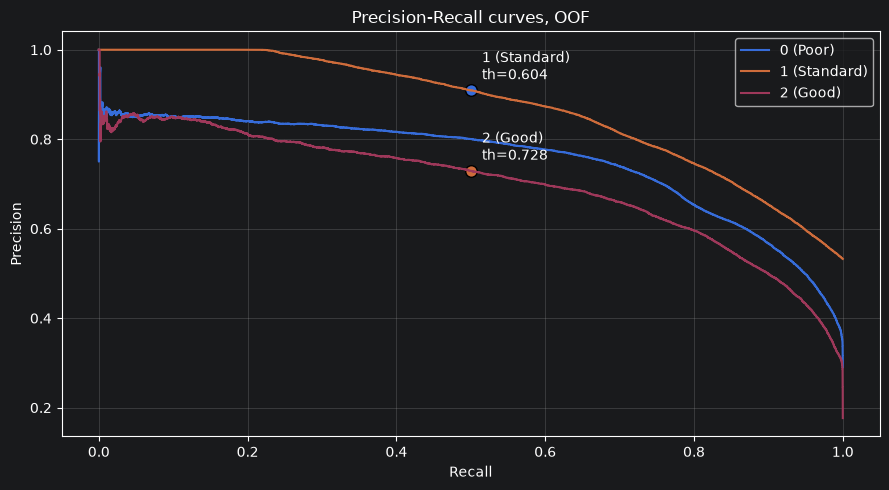

In [12]:
plt.figure(figsize=(9, 5))
for class_name, curve in pr_curves.items():
    plt.plot(curve["recall"], curve["precision"], label=class_name)

for _, row in threshold_selection_df.iterrows():
    plt.scatter(row["recall_at_threshold"], row["precision_at_threshold"], s=70, edgecolor="black")
    plt.annotate(
        f"{row['class']}\nth={row['threshold']:.3f}",
        xy=(row["recall_at_threshold"], row["precision_at_threshold"]),
        xytext=(8, 8),
        textcoords="offset points",
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall curves, OOF")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()